## ECE1513 Tutorial 11:
### Implementing a simple CNN in PyTorch: Training, Testing, and Validation


In [ ]:
# Import necessary libraries
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import os
from datasets import load_dataset
from torchvision.transforms import ToTensor
import ssl
import certifi
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Check for CUDA availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


#### Prepare the data

In [4]:
# Create a directory for saving the data
if not os.path.exists('./data'):
    os.makedirs('./data')

In [5]:
# Define transformations for training and testing data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [6]:
# Load CIFAR-10 dataset from torchvision
cifar10_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# Create val loader from train loader
# Split train dataset into training and validation datasets
train_set, val_set = torch.utils.data.random_split(cifar10_train, [40000, 10000])
# Load the test dataset
cifar10_test = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Convert to PyTorch DataLoader
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(cifar10_test, batch_size=64, shuffle=False)

# Print dataset sizes
print(f'Train dataset size: {len(train_loader.dataset)}')
print(f'Validation dataset size: {len(val_loader.dataset)}')
print(f'Test dataset size: {len(test_loader.dataset)}')

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 170M/170M [00:01<00:00, 95.2MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Train dataset size: 40000
Validation dataset size: 10000
Test dataset size: 10000


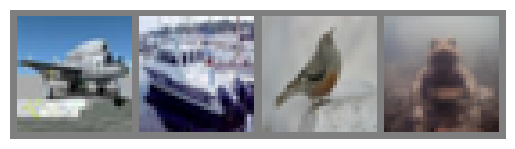

Label 0: plane
Label 8: ship
Label 2: bird
Label 6: frog


In [7]:
#plot some images
def imshow(img):
    img = img / 2 + 0.5     # unnormalize the image for display
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# get the first batch of training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show only the first 4 images in the batch
imshow(torchvision.utils.make_grid(images[:4]))

# Define CIFAR-10 classes
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Print the numerical labels and their corresponding class names for the first 4 images
for i in range(4):
    print(f'Label {labels[i].item()}: {classes[labels[i]]}')

#### Define the CNN model

In [8]:
# Define a simple CNN model. Recall that CIFAR-10 images are 32x32 pixels and have 3 channels (RGB).
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), # CIFAR-10 has 3 channels. Given the input size of 32x32, the output size will be 32x32 and 32 channels
            # Recall that if we have a kernel size of k and padding p, the output size is given by (input_size - k + 2p)/s + 1 where s is the stride. Here we have a stride of 1.
            # So the output size is (32 - 3 + 2*1)/1 + 1 = 32
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2), # Output size will be 16x16. the pooling layer choses the maximum value in a 2x2 window and reduces the size by half.
            # The kernel size is 2 and the stride is 2. So the output size is (32 - 2)/2 + 1 = 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32 channels in, 64 channels out but same size (16x16)
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2) # Output size will be 8x8. In summary, the final output of the conv layers will be 64 channels of size 8x8.
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(), # Flatten the output from the conv layers so the input to the first linear layer is 64*8*8
            nn.Linear(64 * 8 * 8, 128), # output size will be 128
            nn.ReLU(),
            nn.Linear(128, 10) # output size will be 10 (one for each class)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [9]:
# Instantiate model, define loss and optimizer
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Define the train and validation loop

In [10]:
# Training function
def train(model, loader):
    model.train()
    total_loss = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images) # Forward pass
        loss = criterion(outputs, labels) # Compute loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights
        total_loss += loss.item()
    return total_loss / len(loader)

In [11]:
# Validation/Test function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # Forward pass
            _, predicted = torch.max(outputs, 1) # Get the predicted class
            total += labels.size(0) # Total number of samples
            correct += (predicted == labels).sum().item() # Count the number of correct predictions
    return 100 * correct / total

#### Train the model!

In [12]:
train_losses = []
train_accuracies = []
val_accuracies = []
num_epochs = 20

# Train and validate for multiple epochs
for epoch in range(num_epochs):
    train_loss = train(model, train_loader)

    train_accuracy = evaluate(model, train_loader)
    val_accuracy = evaluate(model, val_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    
    print(f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, train accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%')

Epoch 1, Train Loss: 1.3820, train accuracy: 62.63%, Validation Accuracy: 59.39%
Epoch 2, Train Loss: 0.9996, train accuracy: 70.01%, Validation Accuracy: 65.55%
Epoch 3, Train Loss: 0.8403, train accuracy: 72.69%, Validation Accuracy: 65.96%
Epoch 4, Train Loss: 0.7148, train accuracy: 80.28%, Validation Accuracy: 70.11%
Epoch 5, Train Loss: 0.6053, train accuracy: 83.68%, Validation Accuracy: 71.15%
Epoch 6, Train Loss: 0.4969, train accuracy: 87.40%, Validation Accuracy: 70.56%
Epoch 7, Train Loss: 0.3942, train accuracy: 91.31%, Validation Accuracy: 71.13%
Epoch 8, Train Loss: 0.3036, train accuracy: 94.04%, Validation Accuracy: 70.84%
Epoch 9, Train Loss: 0.2281, train accuracy: 95.18%, Validation Accuracy: 70.05%
Epoch 10, Train Loss: 0.1655, train accuracy: 96.10%, Validation Accuracy: 70.16%
Epoch 11, Train Loss: 0.1231, train accuracy: 95.23%, Validation Accuracy: 69.03%
Epoch 12, Train Loss: 0.1036, train accuracy: 97.70%, Validation Accuracy: 70.33%
Epoch 13, Train Loss: 0.0

In [13]:
#plot the learning curve
def plot_learning_curve(train_losses, train_accuracies, val_accuracies):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.plot(range(1, len(train_losses)+1), train_losses, label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 3, 2)
    plt.plot(range(1, len(train_losses)+1), train_accuracies, label='Train Accuracy', color='green')
    plt.plot(range(1, len(train_losses)+1), val_accuracies, label='Validation Accuracy', color='orange')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()

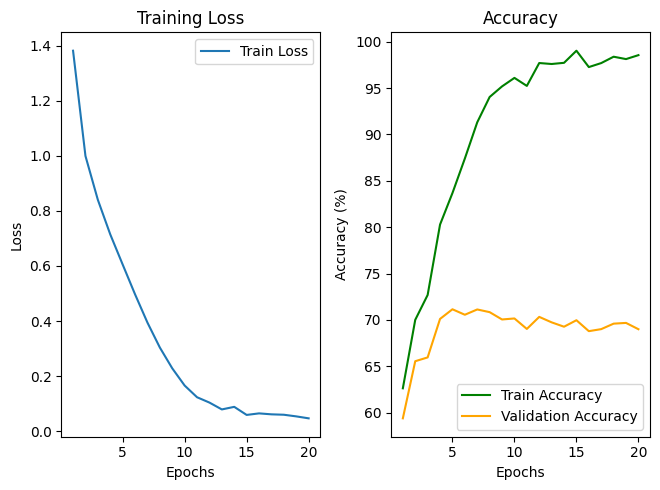

In [14]:
plot_learning_curve(train_losses, train_accuracies, val_accuracies)

In [15]:
# Evaluate the model on test data
test_accuracy = evaluate(model, test_loader)
print(f'Test Accuracy: {test_accuracy:.2f}%')

Test Accuracy: 68.16%
